# reference molecule data


In [ ]:
import os
import sys
import pandas as pd

CODE_PATH = "/home/user-home/fanzhehuan/myprojects/MolGenBench"
sys.path.append(CODE_PATH)

from sup_info.utils import uniprot_in_trainset


data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/MolGenBench_Version3"

ref_df_all = []
for uniprot in os.listdir(data_path):
    ref_df = pd.read_csv(os.path.join(data_path, uniprot, "reference_active_molecules", "ChemFilter.csv"))
    ref_df_all.append(ref_df)

merged_df_ref = pd.concat(ref_df_all).reset_index(drop=True)


def get_reference_stats(merged_df_ref, protein_type='all_proteins'):

    if protein_type == 'all_proteins':
        pass
    elif protein_type == 'unseen_proteins':
        merged_df_ref = merged_df_ref[~merged_df_ref['uniprot'].isin(uniprot_in_trainset)]
    elif protein_type == 'seen_proteins':
        merged_df_ref = merged_df_ref[merged_df_ref['uniprot'].isin(uniprot_in_trainset)]
        
    print(merged_df_ref['uniprot'].nunique())
    
    reference_pass_all = merged_df_ref["ChemFilter"].mean()
    
    merged_df_ref_scaffold  = merged_df_ref[merged_df_ref['ChemFilter'] == True].reset_index()
    reference_pass_all_scaffold = merged_df_ref_scaffold.groupby(['uniprot'])['scaffold'].nunique().sum() / (len(merged_df_ref))

    return reference_pass_all, reference_pass_all_scaffold


for protein_type in ["all_proteins", "seen_proteins", "unseen_proteins"]:
    reference_pass_all, reference_pass_all_scaffold = get_reference_stats(merged_df_ref, protein_type=protein_type)
    print(f"{protein_type}: {reference_pass_all}, {reference_pass_all_scaffold}")

120
all_proteins: 0.6838792326889851, 0.2778733552874463
85
seen_proteins: 0.6696572942867409, 0.2687915468918433
35
unseen_proteins: 0.7111884945448272, 0.29531243261891416


# Draw

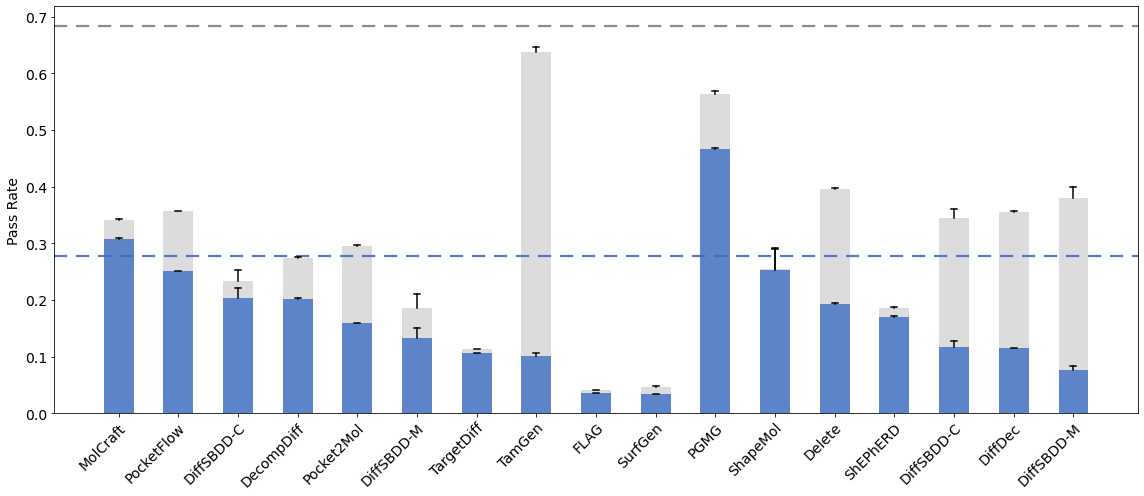

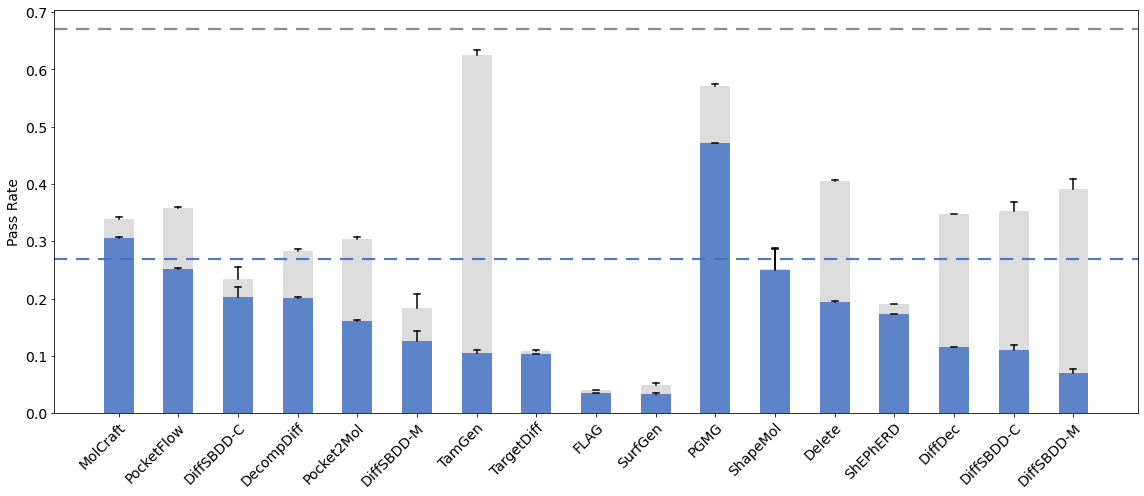

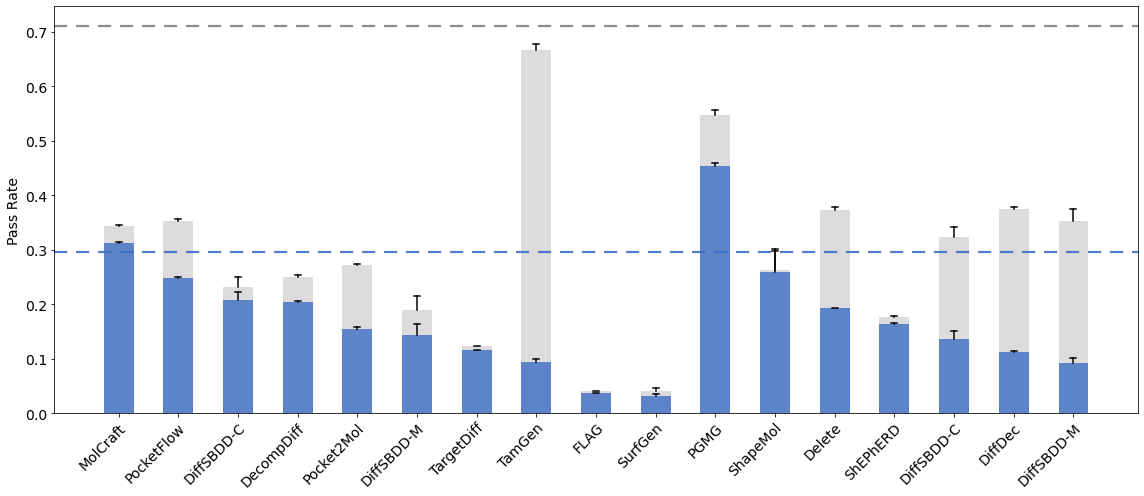

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt


data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results", "Hit_to_Lead_Results"]


TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "DiffSBDD-C",
    "diffSBDD_cond_moad_generated_molecules": "DiffSBDD-M",
}

TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "PGMG_Hit_to_Lead",
    "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "DiffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "DiffSBDD-M",
    "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "ShEPhERD",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
    "PGMG_Hit_to_Lead": "PGMG",
}

results_all = []
results_seen = []
results_unseen = []

for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
            task_type = "De novo"
        else:
            task_list = TASK_LIST_H2L
            name_mapping = H2L_NAME_MAPPING
            task_type = "Hit to Lead"
        
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)

                results_all.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "smiles_pass_rate": result['metrics']['ChemFilter']['all']['smiles_pass_rate'],
                    "scaffold_pass_rate": result['metrics']['ChemFilter']['all']['scaffold_pass_rate'],
                })
                
                results_seen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "smiles_pass_rate": result['metrics']['ChemFilter']['seen']['smiles_pass_rate'],
                    "scaffold_pass_rate": result['metrics']['ChemFilter']['seen']['scaffold_pass_rate'],
                })
                
                results_unseen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "smiles_pass_rate": result['metrics']['ChemFilter']['unseen']['smiles_pass_rate'],
                    "scaffold_pass_rate": result['metrics']['ChemFilter']['unseen']['scaffold_pass_rate'],
                })
                

df_results_all = pd.DataFrame(results_all)
df_results_seen = pd.DataFrame(results_seen)
df_results_unseen = pd.DataFrame(results_unseen)

# ========== 数据聚合函数：计算 mean 和 var ==========
def aggregate_results(df):
    """
    将多个 Round 的数据聚合为 mean 和 var
    """
    agg_df = df.groupby(['Model', 'Type']).agg(
        pass_chem_mean=('smiles_pass_rate', 'mean'),
        pass_chem_var=('smiles_pass_rate', 'var'),
        pass_chem_and_scaffold_unique_mean=('scaffold_pass_rate', 'mean'),
        pass_chem_and_scaffold_unique_var=('scaffold_pass_rate', 'var'),
    ).reset_index()

    
    return agg_df

# ========== 绑图 ==========
protein_type_dict = {
    "all": df_results_all,
    "seen": df_results_seen,
    "unseen": df_results_unseen,
}


for protein_type, df_raw in protein_type_dict.items():

    if protein_type == "all":
        reference_pass_all, reference_pass_all_scaffold = 0.6838792326889851, 0.27793242464964485
    elif protein_type == "seen":
        reference_pass_all, reference_pass_all_scaffold = 0.6696572942867409, 0.2688420768954366
    elif protein_type == "unseen":
        reference_pass_all, reference_pass_all_scaffold = 0.7111884945448272, 0.295387899435077
    
    # 聚合数据
    df_agg = aggregate_results(df_raw)
    
    # 分离 De novo 和 Hit to Lead
    df_denovo = df_agg[df_agg['Type'] == 'De novo'].copy()
    df_hit2lead = df_agg[df_agg['Type'] == 'Hit to Lead'].copy()
    
    # 排序
    df_denovo = df_denovo.sort_values(by="pass_chem_and_scaffold_unique_mean", ascending=False)
    df_hit2lead = df_hit2lead.sort_values(by="pass_chem_and_scaffold_unique_mean", ascending=False)

    # 合并
    df_all = pd.concat([df_denovo, df_hit2lead], ignore_index=True)

    fig, ax = plt.subplots(figsize=(16, 7))

    # Create positions for the bars
    x_pos = np.arange(len(df_all["Model"]))
    bar_width = 0.5

    # reference
    ax.axhline(
        reference_pass_all,
        color="gray",
        linestyle=(0, (6, 4)),
        linewidth=2.2,
        label="Pass All Chem Filters (Reference)",
        alpha=0.9
    )

    # "Unique Scaffolds" reference
    ax.axhline(
        reference_pass_all_scaffold,
        color="#3D6EC4",
        linestyle=(0, (6, 4)),
        linewidth=2.2,
        label="Pass All Chem Filters & Unique Scaffolds (Reference)",
        alpha=0.9
    )

    # Create bars for pass_all (empty/hollow bars)
    bars1 = ax.bar(x_pos, df_all["pass_chem_mean"], 
                bar_width,
                label="Pass All Chem Filters", 
                color="#D4D4D4", 
                linewidth=1.5,
                alpha=0.8,
                capsize=3)

    bars2 = ax.bar(x_pos, df_all["pass_chem_and_scaffold_unique_mean"], 
                bar_width,
                label="Pass All Chem Filters & Unique Scaffolds", 
                color="#3D6EC4", 
                alpha=0.8,
                )

    # ============================
    # error bar
    # ============================
    for i, (bar, mean, var) in enumerate(zip(bars1, df_all["pass_chem_mean"], df_all["pass_chem_var"])):
        err = np.sqrt(var)
        ax.plot([bar.get_x() + bar.get_width() / 2, bar.get_x() + bar.get_width() / 2],
                [mean, mean + err],
                color='black', linewidth=1.5)
        ax.plot([bar.get_x() + bar.get_width() / 2 - 0.05, bar.get_x() + bar.get_width() / 2 + 0.05],
                [mean + err, mean + err],
                color='black', linewidth=1.5)

    for i, (bar, mean, var) in enumerate(zip(bars2, df_all["pass_chem_and_scaffold_unique_mean"], df_all["pass_chem_and_scaffold_unique_var"])):
        err = np.sqrt(var)
        ax.plot([bar.get_x() + bar.get_width() / 2, bar.get_x() + bar.get_width() / 2],
                [mean, mean + err],
                color='black', linewidth=1.5)
        ax.plot([bar.get_x() + bar.get_width() / 2 - 0.05, bar.get_x() + bar.get_width() / 2 + 0.05],
                [mean + err, mean + err],
                color='black', linewidth=1.5)
        
    ax.set_ylabel("Pass Rate", fontsize=14)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df_all["Model"], rotation=45, ha='right', rotation_mode='anchor', fontsize=14,)
    ax.tick_params(axis='y', labelsize=14)

    plt.tight_layout()
    
    # 保存图片
    save_dir = '../final_plot/output'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, f'09-post_filter_merge_{protein_type}.svg'), format='svg')

    plt.show()
    plt.close()